## Este sí produce los beneficios bien

In [55]:
import pandas as pd

In [56]:
estadistica = 'promedio'
T= 300
G = 36


In [57]:
df=pd.read_csv(f'symmetric/{G}redes{estadistica}/resultados_Estimaciones_{T}.csv')

df["cluster"] = pd.to_numeric(df["cluster"], errors="coerce")
df=df[df["cluster"].notna()]



In [58]:
import ast
import numpy as np
import pandas as pd

# =========================================================
# 1) Parser robusto para columnas que vienen como listas
# =========================================================
def _to_array24(x):
    if isinstance(x, np.ndarray):
        arr = x.astype(float).reshape(-1)
    elif isinstance(x, list):
        arr = np.asarray(x, dtype=float).reshape(-1)
    elif isinstance(x, str):
        arr = np.asarray(ast.literal_eval(x), dtype=float).reshape(-1)
    else:
        raise ValueError(f"No pude convertir a array: {type(x)}")

    if arr.size != 24:
        raise ValueError(f"Esperaba longitud 24 y llegó {arr.size}")
    return arr


def _safe_float(x, default=0.0):
    try:
        v = float(x)
        if np.isfinite(v):
            return v
        return default
    except:
        return default


# =========================================================
# 2) Construir juego para un solo día
# =========================================================
def build_juego_from_day(df_day, bid_col="est_uni"):
    """
    df_day: subconjunto de un solo día
    bid_col: columna que usarás como oferta/bid
             por ejemplo 'est_uni', 'est_dis' o 'precio_d'
    """
    df_day = df_day.copy()

    # demanda diaria de 24 horas: tomo la primera no nula
    demand_val = None
    for x in df_day["daily_reman_demand"]:
        if pd.notna(x):
            demand_val = x
            break
    if demand_val is None:
        raise ValueError("No encontré daily_reman_demand para este día")

    demanda24 = _to_array24(demand_val)

    juego = {
        "I": np.asarray(df_day["id_planta"].astype(int).tolist(), dtype=int),
        "demanda": demanda24,
    }

    meta_cols = [
        "CodigoPlanta", "phi", "precio_d", "Fecha", "cluster",
        "id_planta", "daily_reman_demand", "Grupo", "est_uni", "est_dis"
    ]

    for _, row in df_day.iterrows():
        pid = int(row["id_planta"])

        juego[pid] = {
            "beta": _safe_float(row[bid_col], default=0.0),
            "available_q": _to_array24(row["available_q"]),
        }

        for col in meta_cols:
            if col in row.index:
                juego[pid][col] = row[col]

    return juego


# =========================================================
# 3) Aplanar equilibrio a nivel planta-día
# =========================================================
def flatten_eq_daily(eq):
    rows = []

    pricing = eq["pricing"]
    price24_sys = eq["price24"]

    for pid in eq["I"]:
        pid = int(pid)
        x = eq[pid]

        q = np.asarray(x["cantidades_despachadas"], dtype=float).reshape(24)
        p = np.asarray(x["precio24"], dtype=float).reshape(24)

        row = {
            "Fecha": x.get("Fecha"),
            "id_planta": x.get("id_planta", pid),
            "CodigoPlanta": x.get("CodigoPlanta"),
            "Grupo": x.get("Grupo"),
            "cluster": x.get("cluster"),
            "phi": x.get("phi"),
            "precio_d": x.get("precio_d"),
            "est_uni": x.get("est_uni"),
            "est_dis": x.get("est_dis"),
            "bid": x["beta"],
            "pricing": pricing,
            "cantidades_despachadas": q.tolist(),
            "precio24": p.tolist(),
            "price24_sistema": np.asarray(price24_sys, dtype=float).tolist(),
            "sumaq": float(q.sum()),
            "ingreso_total": float((q * p).sum()),
        }
        rows.append(row)

    out = pd.DataFrame(rows)
    if "Fecha" in out.columns:
        out["Fecha"] = pd.to_datetime(out["Fecha"])
    return out


# =========================================================
# 4) Expandir a nivel planta-día-hora
# =========================================================
def explode_dispatch_hourly(df_daily_eq):
    rows = []

    for _, row in df_daily_eq.iterrows():
        q = np.asarray(row["cantidades_despachadas"], dtype=float).reshape(24)
        p = np.asarray(row["precio24"], dtype=float).reshape(24)
        ps = np.asarray(row["price24_sistema"], dtype=float).reshape(24)

        for h in range(24):
            rows.append({
                "Fecha": row["Fecha"],
                "hora": h,
                "id_planta": row["id_planta"],
                "CodigoPlanta": row["CodigoPlanta"],
                "Grupo": row["Grupo"],
                "cluster": row["cluster"],
                "phi": row["phi"],
                "pricing": row["pricing"],
                "bid": row["bid"],
                "cantidad_despachada": float(q[h]),
                "precio_pagado": float(p[h]),
                "precio_sistema": float(ps[h]),
                "ingreso_hora": float(q[h] * p[h]),
            })

    out = pd.DataFrame(rows)
    if "Fecha" in out.columns:
        out["Fecha"] = pd.to_datetime(out["Fecha"])
    return out

import numpy as np

def compute_equilibrio_dispatch(juego: dict, pricing: str = "uniform", unmet_price="max_accepted"):
    """
    unmet_price:
      - número (float): usa ese precio si no hay dispatch
      - "max_accepted": si no hay dispatch, usa max bid positivo del sistema (si existe; si no, 0)
    """
    pricing = pricing.lower().strip()
    if pricing not in {"uniform", "pay_as_bid"}:
        raise ValueError("pricing must be 'uniform' or 'pay_as_bid'")

    # ids
    if "I" in juego:
        plant_ids = [int(x) for x in np.asarray(juego["I"]).reshape(-1)]
    else:
        plant_ids = [k for k in juego.keys() if isinstance(k, (int, np.integer))]

    if len(plant_ids) == 0:
        raise ValueError("No plant ids found in juego")

    demand24 = np.asarray(juego["demanda"], dtype=float).reshape(24)
    bids = np.array([float(juego[pid]["beta"]) for pid in plant_ids], dtype=float)
    avail_mat = np.vstack([
        np.asarray(juego[pid]["available_q"], dtype=float).reshape(24)
        for pid in plant_ids
    ])

    I = len(plant_ids)
    disp_mat = np.zeros((I, 24), dtype=float)
    price24 = np.zeros(24, dtype=float)

    # merit order: solo bids positivos
    active = bids > 0
    order = np.array([], dtype=int)
    if np.any(active):
        order = np.where(active)[0][np.argsort(bids[active], kind="mergesort")]

    max_bid_pos = float(np.max(bids[active])) if np.any(active) else 0.0

    for h in range(24):
        remaining = float(max(demand24[h], 0.0))
        if remaining <= 0:
            price24[h] = 0.0
            continue

        av_h = np.maximum(avail_mat[:, h], 0.0)
        last_bid = None
        any_dispatch = False

        for i in order:
            if remaining <= 0:
                break
            take = min(av_h[i], remaining)
            if take > 0:
                disp_mat[i, h] = take
                remaining -= take
                any_dispatch = True
                last_bid = float(bids[i])

        if any_dispatch:
            price24[h] = float(last_bid)
        else:
            if unmet_price == "max_accepted":
                price24[h] = max_bid_pos
            else:
                price24[h] = float(unmet_price)

    if pricing == "uniform":
        precio_mat = np.where(disp_mat > 0.0, price24.reshape(1, 24), 0.0)
    else:
        precio_mat = np.where(disp_mat > 0.0, bids.reshape(I, 1), 0.0)

    eq = {
        "I": np.array(plant_ids, dtype=int),
        "demanda": demand24.copy(),
        "pricing": pricing,
        "price24": price24.copy(),
    }

    meta_cols = [
        "CodigoPlanta", "phi", "precio_d", "Fecha", "cluster",
        "id_planta", "daily_reman_demand", "Grupo", "est_uni", "est_dis"
    ]

    for idx, pid in enumerate(plant_ids):
        q = disp_mat[idx, :].copy()

        eq[pid] = {
            "beta": float(bids[idx]),
            "available_q": avail_mat[idx, :].copy(),
            "cantidades_despachadas": q,
            "precio24": precio_mat[idx, :].copy(),
            "sumaq": float(q.sum()),
        }

        if isinstance(juego.get(pid, {}), dict):
            for col in meta_cols:
                if col in juego[pid]:
                    val = juego[pid][col]
                    if isinstance(val, (list, tuple, np.ndarray)):
                        eq[pid][col] = np.asarray(val).copy()
                    else:
                        eq[pid][col] = val

        if "id_planta" not in eq[pid]:
            eq[pid]["id_planta"] = int(pid)

    return eq
# =========================================================
# 5) Correr todo el panel por fecha
# =========================================================
def compute_dispatch_panel(df, bid_col="est_uni", pricing="uniform", unmet_price="max_accepted"):
    """
    df: tu base completa con muchas fechas
    bid_col:
        - "est_uni"  para usar los bids estimados bajo uniforme
        - "est_dis"  para usar los bids estimados bajo discriminatorio
        - "precio_d" si quieres usar esa columna como bid
    pricing:
        - "uniform"
        - "pay_as_bid"
    """
    df = df.copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    daily_results = []

    for fecha, g in df.sort_values(["Fecha", "id_planta"]).groupby("Fecha", sort=True):
        juego = build_juego_from_day(g, bid_col=bid_col)
        eq = compute_equilibrio_dispatch(
            juego=juego,
            pricing=pricing,
            unmet_price=unmet_price
        )
        df_eq_day = flatten_eq_daily(eq)
        daily_results.append(df_eq_day)

    df_daily_eq = pd.concat(daily_results, ignore_index=True)
    df_hourly_eq = explode_dispatch_hourly(df_daily_eq)

    return df_daily_eq, df_hourly_eq

## Uniform

In [59]:
df_uni_daily, df_uni_hourly = compute_dispatch_panel(
    df,
    bid_col="est_uni",
    pricing="uniform"
)

In [60]:
cluster_numeric = pd.to_numeric(df_uni_daily["cluster"], errors="coerce")

df_filtrado = df_uni_daily[
    (cluster_numeric.isna()) &
    (df_uni_daily["ingreso_total"] > 0)
]

df_filtrado

,Fecha,id_planta,CodigoPlanta,Grupo,cluster,phi,precio_d,est_uni,est_dis,bid,pricing,cantidades_despachadas,precio24,price24_sistema,sumaq,ingreso_total


In [61]:
df_uni_dailyReal, df_uni_hourlyReal = compute_dispatch_panel(
    df,
    bid_col="precio_d",
    pricing="uniform"
)

In [62]:
df_uni_dailyReal

,Fecha,id_planta,CodigoPlanta,Grupo,cluster,phi,precio_d,est_uni,est_dis,bid,pricing,cantidades_despachadas,precio24,price24_sistema,sumaq,ingreso_total
0,2025-04-01,1,TYP3,1,10.0,0.083924,0.10137,0.104433,0.367492,0.10137,uniform,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....","[0.32637, 0.31037, 0.29798, 0.28892, 0.28892, ...","[0.32637, 0.31037, 0.29798, 0.28892, 0.28892, ...",1176.00000,362.109510
1,2025-04-01,3,TSJ2,1,10.0,0.275288,0.32637,0.294840,0.558856,0.32637,uniform,"[17.19274000000007, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.32637, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.32637, 0.31037, 0.29798, 0.28892, 0.28892, ...",718.56297,244.037397
2,2025-04-01,4,TSJ1,1,10.0,0.260380,0.31037,0.279904,0.543948,0.31037,uniform,"[165.0, 88.24010999999996, 0.0, 0.0, 0.0, 0.0,...","[0.32637, 0.31037, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[0.32637, 0.31037, 0.29798, 0.28892, 0.28892, ...",1746.59868,569.811832
3,2025-04-01,5,MRL1,1,10.0,0.968472,1.02813,0.986069,1.252040,1.02813,uniform,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.32637, 0.31037, 0.29798, 0.28892, 0.28892, ...",0.00000,0.000000
4,2025-04-01,6,PPA1,1,10.0,0.290138,0.29798,0.309717,0.573706,0.29798,uniform,"[21.0, 21.0, 17.173630000000003, 0.0, 0.0, 0.0...","[0.32637, 0.31037, 0.29798, 0.0, 0.0, 0.0, 0.0...","[0.32637, 0.31037, 0.29798, 0.28892, 0.28892, ...",290.17363,93.376408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3541,2025-09-09,32,TRN1,1,12.0,0.779362,0.90894,0.797960,1.062930,0.90894,uniform,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.51916, 0.37294, 0.36094, 0.33894, 0.28945, ...",0.00000,0.000000
3542,2025-09-09,33,TBQ4,1,12.0,1.058581,1.11735,1.075360,1.342149,1.11735,uniform,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.51916, 0.37294, 0.36094, 0.33894, 0.28945, ...",0.00000,0.000000
3543,2025-09-09,34,TBQ3,1,12.0,0.945489,1.01274,0.963263,1.229057,1.01274,uniform,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.51916, 0.37294, 0.36094, 0.33894, 0.28945, ...",0.00000,0.000000
3544,2025-09-09,35,TVL1,1,12.0,0.969786,1.18348,0.987371,1.253354,1.18348,uniform,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.51916, 0.37294, 0.36094, 0.33894, 0.28945, ...",0.00000,0.000000


## Discriminatory

In [63]:
df_dis_daily, df_dis_hourly = compute_dispatch_panel(
    df,
    bid_col="est_dis",
    pricing="pay_as_bid"
)

## double check

In [64]:
df_dis_hourly.groupby(['Fecha', 'hora'])['cantidad_despachada'].sum().reset_index()

,Fecha,hora,cantidad_despachada
0,2025-04-01,0,1029.70
1,2025-04-01,1,935.38
2,2025-04-01,2,843.32
3,2025-04-01,3,771.69
4,2025-04-01,4,695.00
...,...,...,...
2803,2025-09-09,19,1435.20
2804,2025-09-09,20,1450.10
2805,2025-09-09,21,1350.18
2806,2025-09-09,22,1320.24


In [65]:
df_uni_hourly.groupby(['Fecha', 'hora'])['cantidad_despachada'].sum().reset_index()

,Fecha,hora,cantidad_despachada
0,2025-04-01,0,1029.70
1,2025-04-01,1,935.38
2,2025-04-01,2,843.32
3,2025-04-01,3,771.69
4,2025-04-01,4,695.00
...,...,...,...
2803,2025-09-09,19,1435.20
2804,2025-09-09,20,1450.10
2805,2025-09-09,21,1350.18
2806,2025-09-09,22,1320.24


In [66]:
df_uni_hourlyReal.groupby(['Fecha', 'hora'])['cantidad_despachada'].sum().reset_index()

,Fecha,hora,cantidad_despachada
0,2025-04-01,0,1029.70
1,2025-04-01,1,935.38
2,2025-04-01,2,843.32
3,2025-04-01,3,771.69
4,2025-04-01,4,695.00
...,...,...,...
2803,2025-09-09,19,1435.20
2804,2025-09-09,20,1450.10
2805,2025-09-09,21,1350.18
2806,2025-09-09,22,1320.24


In [83]:
pd.set
df_uni_hourlyReal.groupby(['Fecha', 'hora'])['cantidad_despachada'].sum().reset_index()

,Fecha,hora,cantidad_despachada
0,2025-04-01,0,1029.70
1,2025-04-01,1,935.38
2,2025-04-01,2,843.32
3,2025-04-01,3,771.69
4,2025-04-01,4,695.00
...,...,...,...
2803,2025-09-09,19,1435.20
2804,2025-09-09,20,1450.10
2805,2025-09-09,21,1350.18
2806,2025-09-09,22,1320.24


In [67]:
## uniforme
ingreso_por_dia_uniforme = (
    df_uni_daily
    .groupby("Fecha", as_index=False)["ingreso_total"]
    .sum()
    .rename(columns={"ingreso_total": "ingreso_total_dia"})
)
# en mil millones
promedio_diario_uniforme = ingreso_por_dia_uniforme["ingreso_total_dia"].mean()/1000

## discriminatorio
ingreso_por_dia_discriminatorio = (
    df_dis_daily
    .groupby("Fecha", as_index=False)["ingreso_total"]
    .sum()
    .rename(columns={"ingreso_total": "ingreso_total_dia"})
)
# en mil millones
promedio_diario_discriminatorio = ingreso_por_dia_discriminatorio["ingreso_total_dia"].mean()/1000

## uniforme
ingreso_por_dia_uniformeReal = (
    df_uni_dailyReal
    .groupby("Fecha", as_index=False)["ingreso_total"]
    .sum()
    .rename(columns={"ingreso_total": "ingreso_total_dia"})
)
# en mil millones
promedio_diario_uniformeReal = ingreso_por_dia_uniformeReal["ingreso_total_dia"].mean()/1000



In [68]:
ingreso_por_dia_uniformeReal

,Fecha,ingreso_total_dia
0,2025-04-01,6638.676416
1,2025-04-02,7561.420121
2,2025-04-03,7292.604962
3,2025-04-04,6325.592709
4,2025-04-07,6559.725141
...,...,...
112,2025-09-03,16133.790873
113,2025-09-04,22426.281332
114,2025-09-05,18996.111172
115,2025-09-08,10019.955492


In [69]:
f'symmetric/{G}redes{estadistica}/payment_{T}.csv'

'symmetric/36redespromedio/payment_300.csv'

In [70]:
df_final = pd.DataFrame({
    'pagoPlanta_uniforme': [promedio_diario_uniforme],
    'pagoPlanta_discriminatorio': [promedio_diario_discriminatorio],
    'pagoPlanta_uniformeReal': [promedio_diario_uniformeReal]
})
df_final.to_csv(f'symmetric/{G}redes{estadistica}/payment_{T}.csv', index=False)
df_final
# en mil millones

,pagoPlanta_uniforme,pagoPlanta_discriminatorio,pagoPlanta_uniformeReal
0,7.150291,9.939338,11.293037


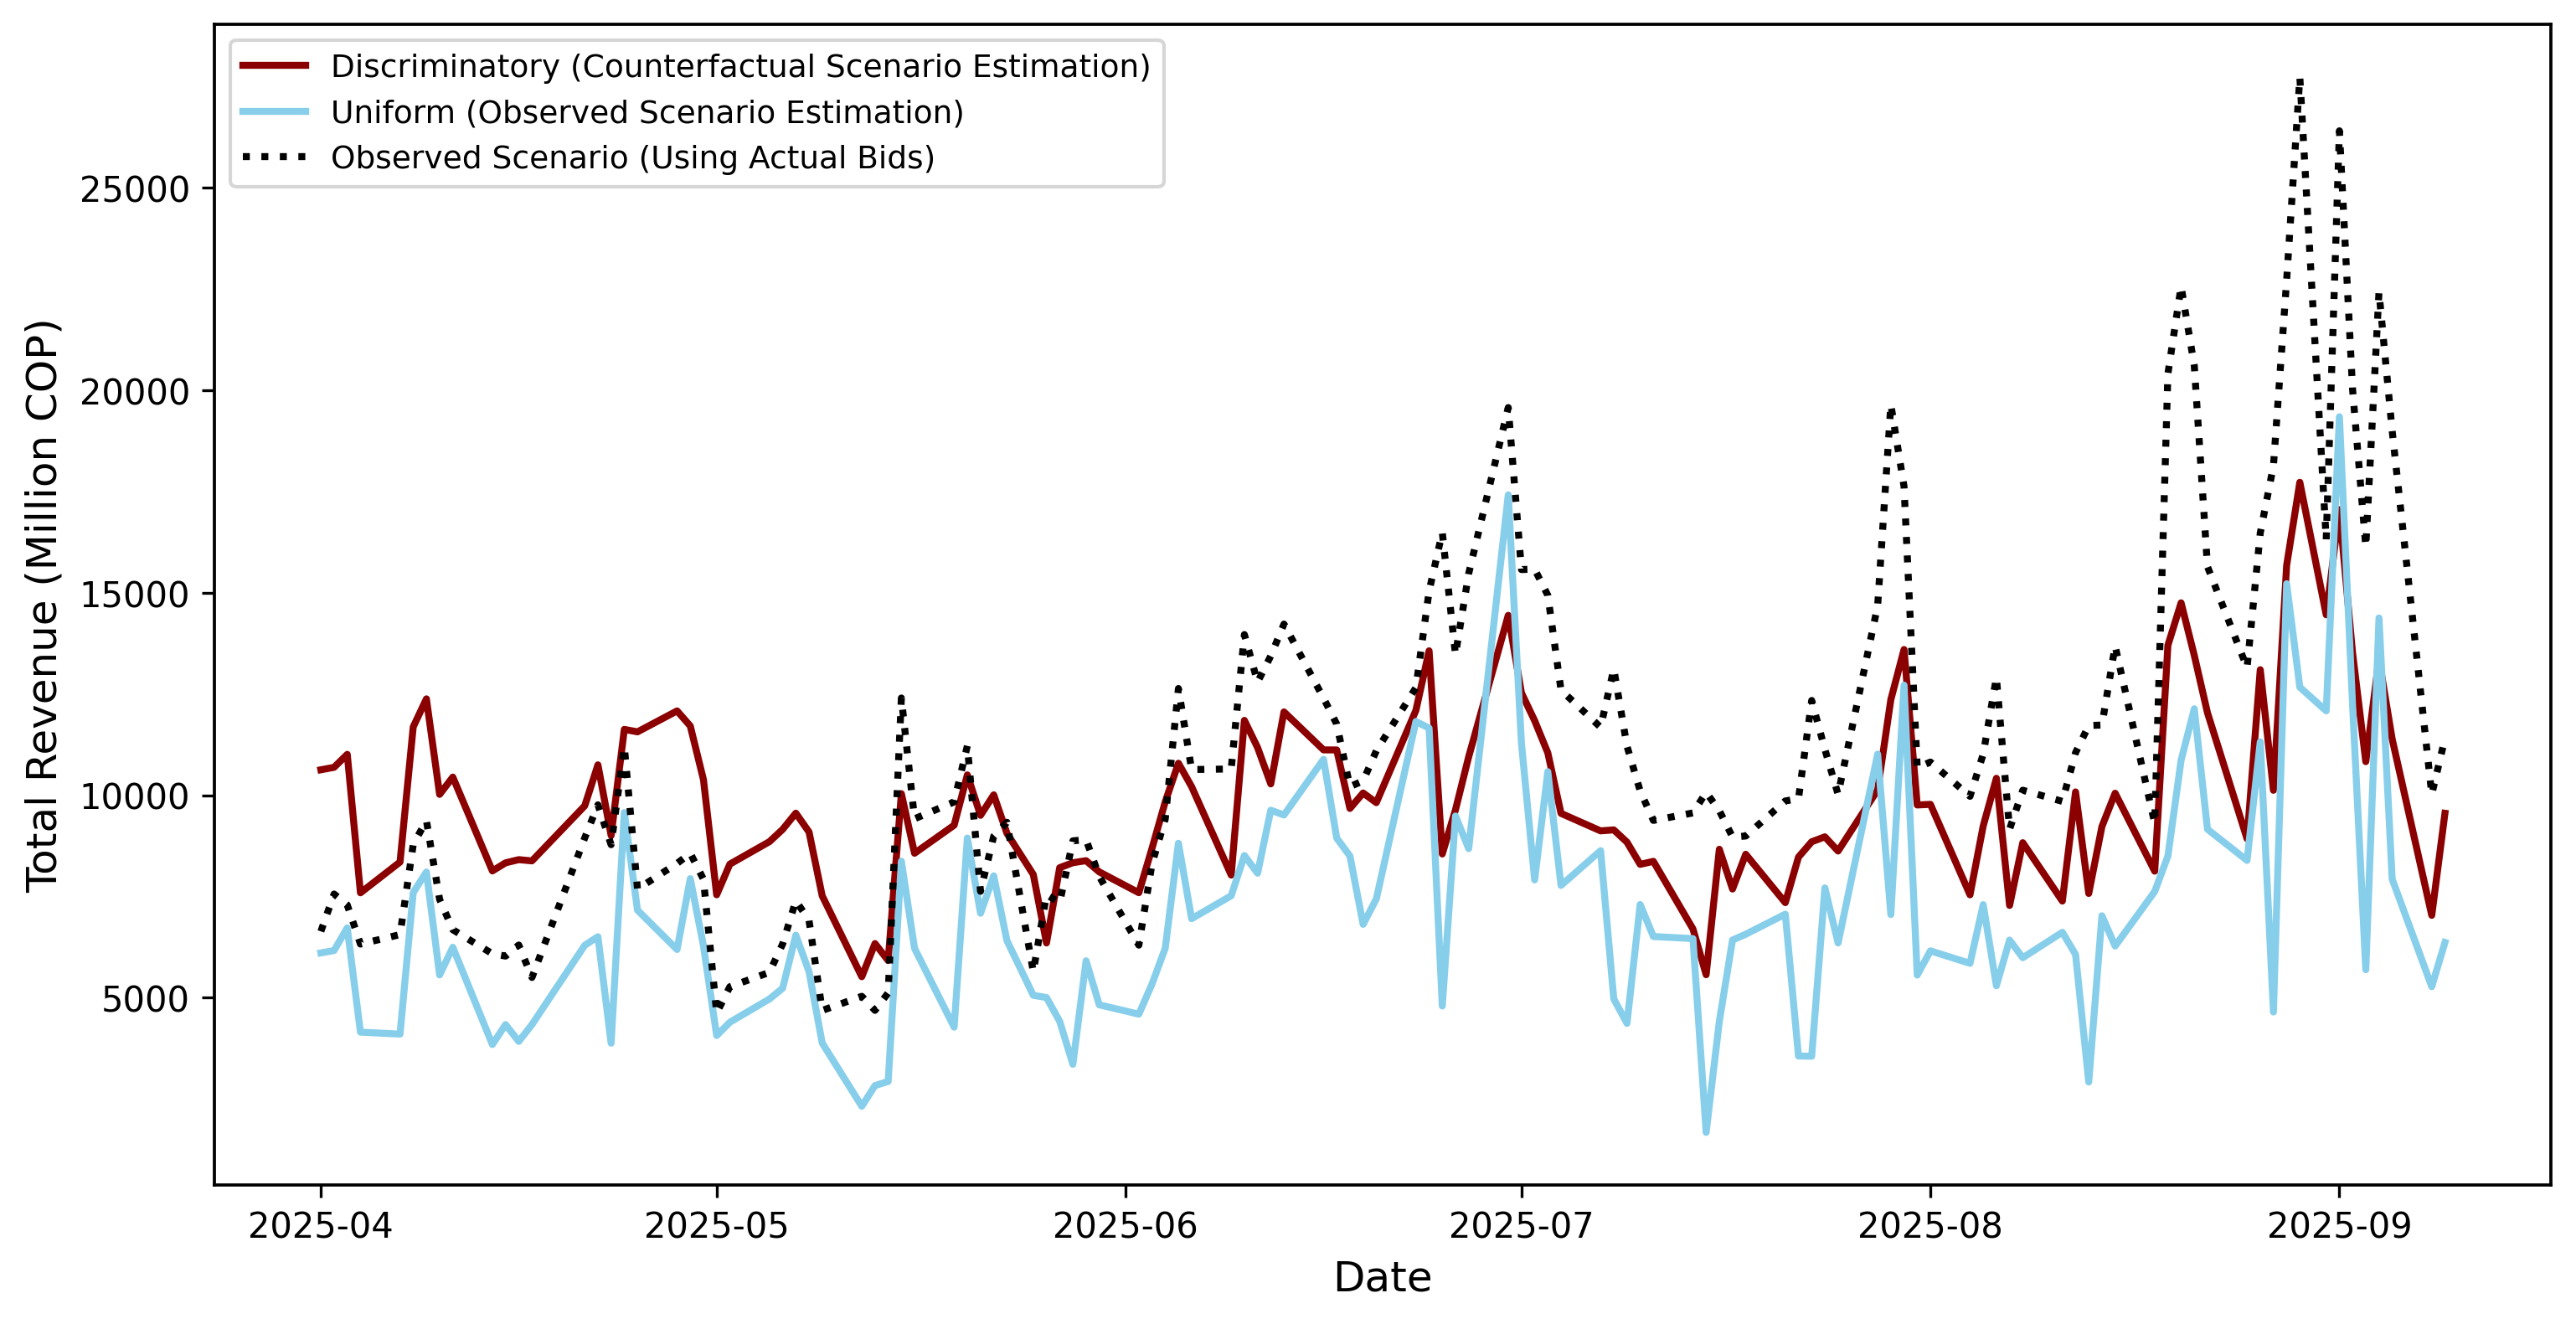

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    ingreso_por_dia_uniformeReal["Fecha"],
    ingreso_por_dia_discriminatorio["ingreso_total_dia"],
    color="darkred",
    label="Discriminatory (Counterfactual Scenario Estimation)",
    linewidth=2
)

plt.plot(
    ingreso_por_dia_uniformeReal["Fecha"],
    ingreso_por_dia_uniforme["ingreso_total_dia"],
    color="skyblue",
    label="Uniform (Observed Scenario Estimation)",
    linewidth=2
)

plt.plot(
    ingreso_por_dia_uniformeReal["Fecha"],
    ingreso_por_dia_uniformeReal["ingreso_total_dia"],
    color="black",
    linestyle=":",
    label="Observed Scenario (Using Actual Bids)",
    linewidth=2
)

plt.legend()
#plt.title(f'Total Thermal Payments per Day (G={G})')
plt.xlabel("Date")
plt.ylabel("Total Revenue (Million COP)")
plt.savefig(f'symmetric/{G}redes{estadistica}/payment_comparison_{T}.png', dpi=300, bbox_inches='tight')
plt.show()

## Precio uniforme vs discriminatorio

In [72]:
df_uni_hourlyReal

,Fecha,hora,id_planta,CodigoPlanta,Grupo,cluster,phi,pricing,bid,cantidad_despachada,precio_pagado,precio_sistema,ingreso_hora
0,2025-04-01,0,1,TYP3,1,10.0,0.083924,uniform,0.10137,49.0,0.32637,0.32637,15.99213
1,2025-04-01,1,1,TYP3,1,10.0,0.083924,uniform,0.10137,49.0,0.31037,0.31037,15.20813
2,2025-04-01,2,1,TYP3,1,10.0,0.083924,uniform,0.10137,49.0,0.29798,0.29798,14.60102
3,2025-04-01,3,1,TYP3,1,10.0,0.083924,uniform,0.10137,49.0,0.28892,0.28892,14.15708
4,2025-04-01,4,1,TYP3,1,10.0,0.083924,uniform,0.10137,49.0,0.28892,0.28892,14.15708
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85099,2025-09-09,19,36,TEC1,1,12.0,1.255597,uniform,1.48540,0.0,0.00000,0.75924,0.00000
85100,2025-09-09,20,36,TEC1,1,12.0,1.255597,uniform,1.48540,0.0,0.00000,0.75924,0.00000
85101,2025-09-09,21,36,TEC1,1,12.0,1.255597,uniform,1.48540,0.0,0.00000,0.75924,0.00000
85102,2025-09-09,22,36,TEC1,1,12.0,1.255597,uniform,1.48540,0.0,0.00000,0.75924,0.00000


In [73]:
df_dis_hourly

,Fecha,hora,id_planta,CodigoPlanta,Grupo,cluster,phi,pricing,bid,cantidad_despachada,precio_pagado,precio_sistema,ingreso_hora
0,2025-04-01,0,1,TYP3,1,10.0,0.083924,pay_as_bid,0.367492,49.0,0.367492,0.558856,18.007103
1,2025-04-01,1,1,TYP3,1,10.0,0.083924,pay_as_bid,0.367492,49.0,0.367492,0.547786,18.007103
2,2025-04-01,2,1,TYP3,1,10.0,0.083924,pay_as_bid,0.367492,49.0,0.367492,0.543948,18.007103
3,2025-04-01,3,1,TYP3,1,10.0,0.083924,pay_as_bid,0.367492,49.0,0.367492,0.543948,18.007103
4,2025-04-01,4,1,TYP3,1,10.0,0.083924,pay_as_bid,0.367492,49.0,0.367492,0.514775,18.007103
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85099,2025-09-09,19,36,TEC1,1,12.0,1.255597,pay_as_bid,1.538654,0.0,0.000000,0.593257,0.000000
85100,2025-09-09,20,36,TEC1,1,12.0,1.255597,pay_as_bid,1.538654,0.0,0.000000,0.593257,0.000000
85101,2025-09-09,21,36,TEC1,1,12.0,1.255597,pay_as_bid,1.538654,0.0,0.000000,0.593257,0.000000
85102,2025-09-09,22,36,TEC1,1,12.0,1.255597,pay_as_bid,1.538654,0.0,0.000000,0.593257,0.000000


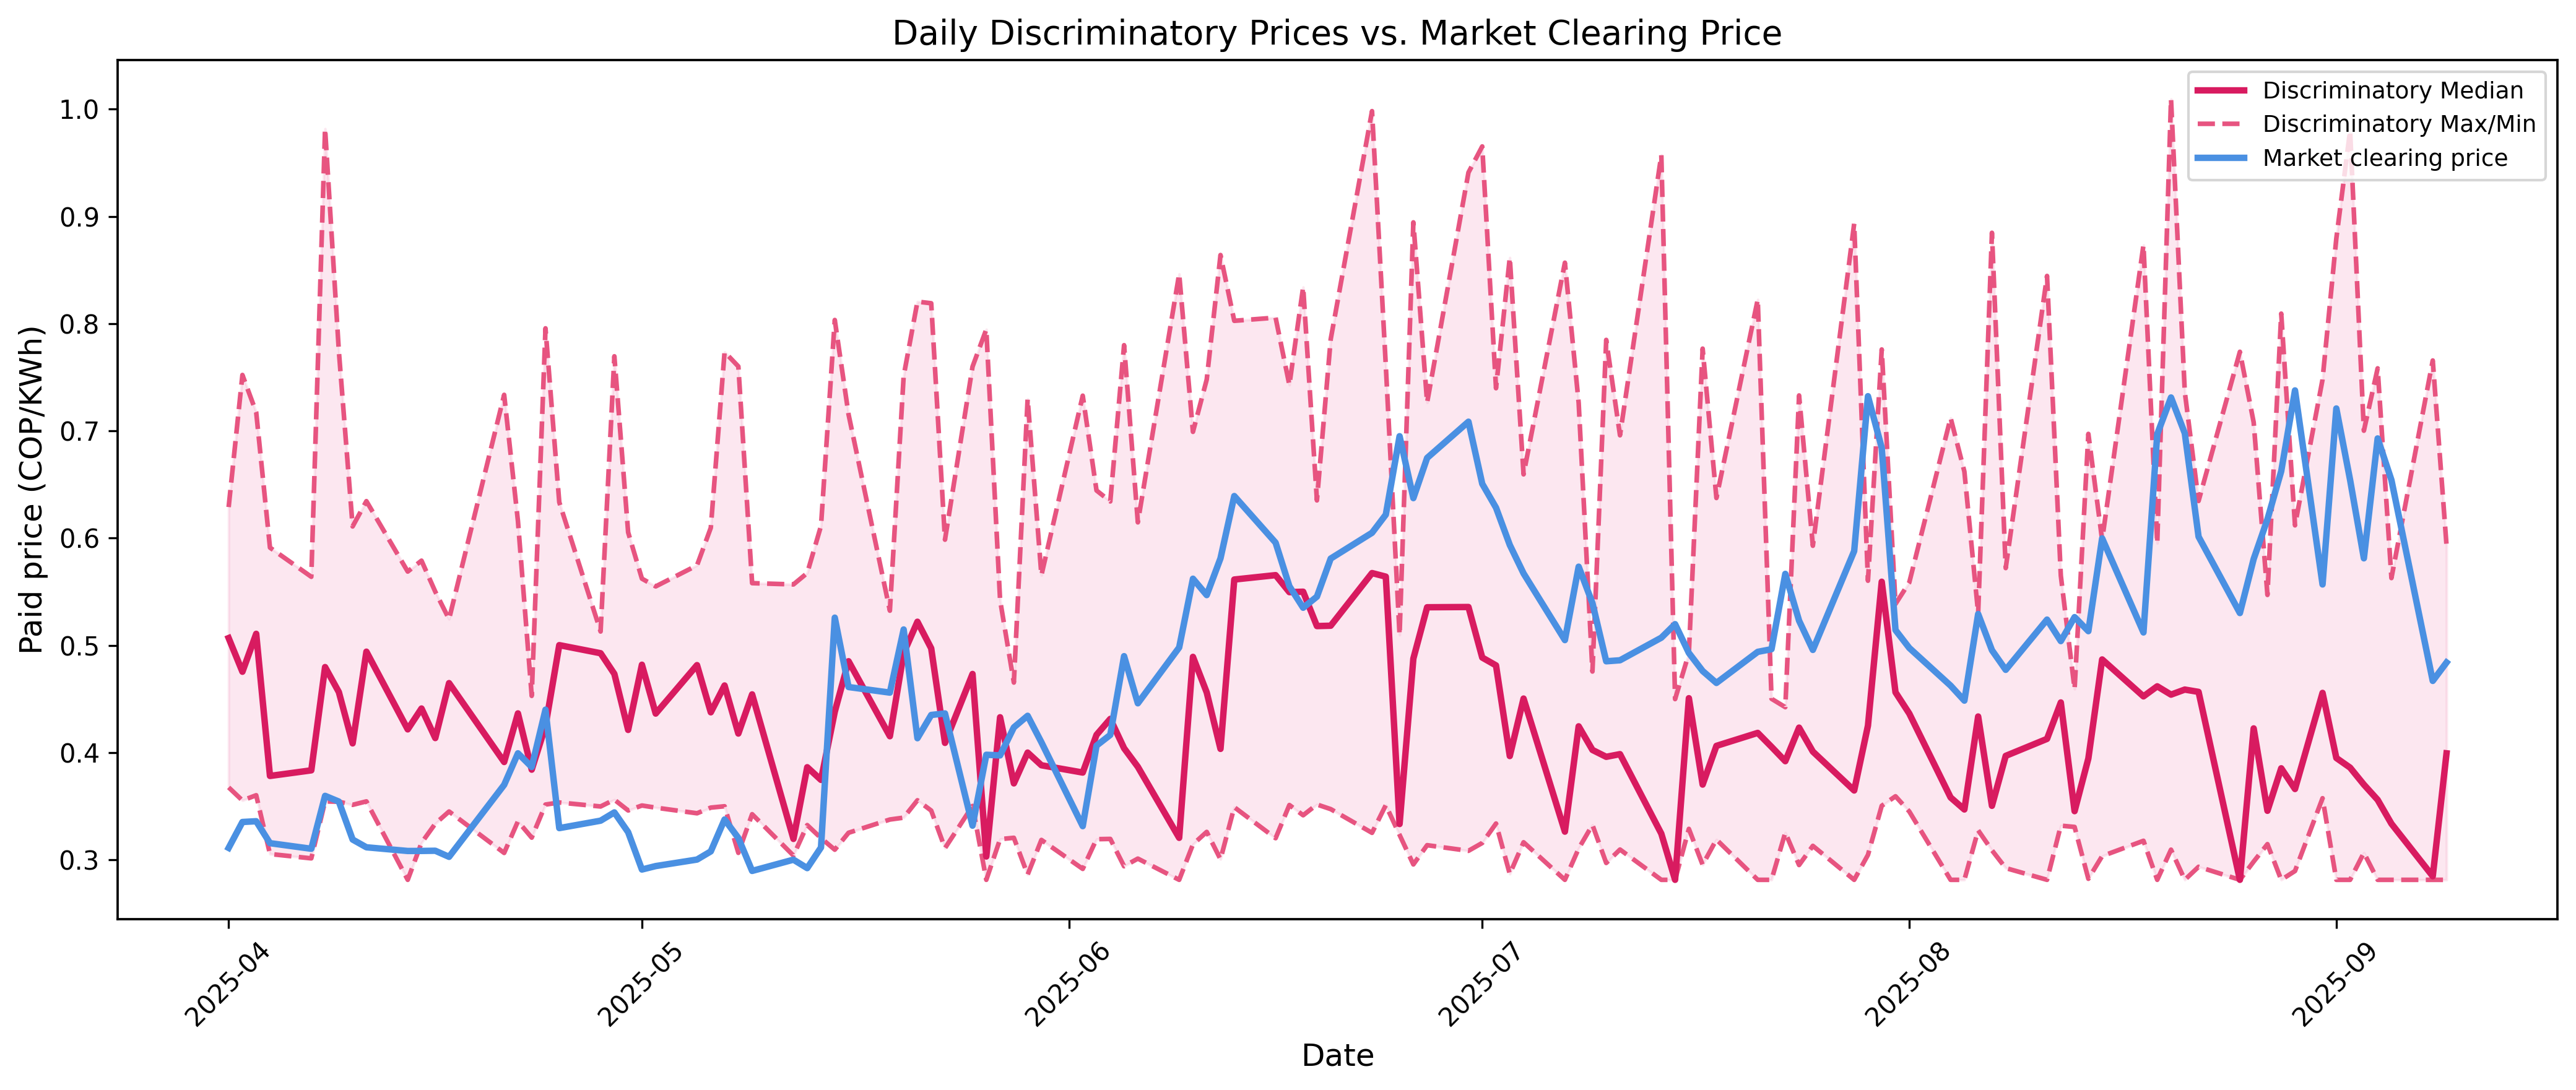

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

df_uni_hourlyReal["Fecha"] = pd.to_datetime(df_uni_hourlyReal["Fecha"])
df_dis_hourly["Fecha"] = pd.to_datetime(df_dis_hourly["Fecha"])

# Excluir ceros
df_uni_no0 = df_uni_hourlyReal[df_uni_hourlyReal["precio_pagado"] != 0].copy()
df_dis_no0 = df_dis_hourly[df_dis_hourly["precio_pagado"] != 0].copy()

df_uni_no0["dia"] = df_uni_no0["Fecha"].dt.date
df_dis_no0["dia"] = df_dis_no0["Fecha"].dt.date

res_dis_dia = (
    df_dis_no0
    .groupby("dia")["precio_pagado"]
    .agg(
        minimo="min",
        mediana="median",
        maximo="max"
    )
    .reset_index()
)

res_uni_dia = (
    df_uni_no0
    .groupby("dia")["precio_pagado"]
    .mean()
    .reset_index(name="media_uniforme")
)

comp_dia = res_dis_dia.merge(res_uni_dia, on="dia", how="inner")
comp_dia["dia"] = pd.to_datetime(comp_dia["dia"])

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Sombrita entre mínimo y máximo discriminatorio
plt.fill_between(
    comp_dia["dia"],
    comp_dia["minimo"],
    comp_dia["maximo"],
    color="#f4a3c4",
    alpha=0.25,
    #label="Rango discriminatorio min-max"
)

# Líneas discriminatorio en rosado
plt.plot(
    comp_dia["dia"],
    comp_dia["minimo"],
    linestyle="--",
    linewidth=1.8,
    color="#e75480",
    #label="Discriminatorio mínimo"
)

plt.plot(
    comp_dia["dia"],
    comp_dia["mediana"],
    linewidth=2.5,
    color="#d81b60",
    label="Discriminatory Median"
)

plt.plot(
    comp_dia["dia"],
    comp_dia["maximo"],
    linestyle="--",
    linewidth=1.8,
    color="#e75480",
    label="Discriminatory Max/Min"
)

# Market clearing price en azul
plt.plot(
    comp_dia["dia"],
    comp_dia["media_uniforme"],
    linewidth=2.5,
    color="#4a90e2",
    label="Market clearing price"
)

plt.xlabel("Date")
plt.ylabel("Paid price (COP/KWh)")
plt.title("Daily Discriminatory Prices vs. Market Clearing Price")
plt.savefig(f'symmetric/{G}redes{estadistica}/PABClearing_{T}.png', dpi=300, bbox_inches='tight')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Story

In [75]:
mask = ingreso_por_dia_uniforme["ingreso_total_dia"] > ingreso_por_dia_discriminatorio["ingreso_total_dia"]

dias_clave = ingreso_por_dia_uniformeReal.loc[mask, "Fecha"]

In [76]:
df_uni_daily["grupo"] = df_uni_daily["Fecha"].isin(dias_clave)
df_dis_daily["grupo"] = df_dis_daily["Fecha"].isin(dias_clave)

df_uni_daily["grupo"] = df_uni_daily["grupo"].map({
    True: "PC > PAB",
    False: "PC ≤ PAB"
})

df_dis_daily["grupo"] = df_dis_daily["grupo"].map({
    True: "PC > PAB",
    False: "PC ≤ PAB"
})

In [77]:
df_uni_daily.groupby("grupo")["est_uni"].describe()

,count,mean,std,min,25%,50%,75%,max
grupo,,,,,,,,
PC > PAB,112.0,0.661286,0.532526,0.022454,0.217571,0.687949,0.894893,2.249913
PC ≤ PAB,3434.0,0.702343,0.537476,0.022454,0.257753,0.646510,0.947546,2.310654


In [78]:

df_dis_daily.groupby("grupo")["est_dis"].describe()

,count,mean,std,min,25%,50%,75%,max
grupo,,,,,,,,
PC > PAB,112.0,0.920584,0.522702,0.281305,0.481730,0.952349,1.160351,2.422662
PC ≤ PAB,3434.0,0.961111,0.525432,0.281305,0.521838,0.910691,1.213264,2.478197


In [79]:
dias_clave

64    2025-06-30
84    2025-07-28
110   2025-09-01
113   2025-09-04
Name: Fecha, dtype: datetime64[us]

Días donde uniform pierde: 4
['2025-06-30', '2025-07-28', '2025-09-01', '2025-09-04']


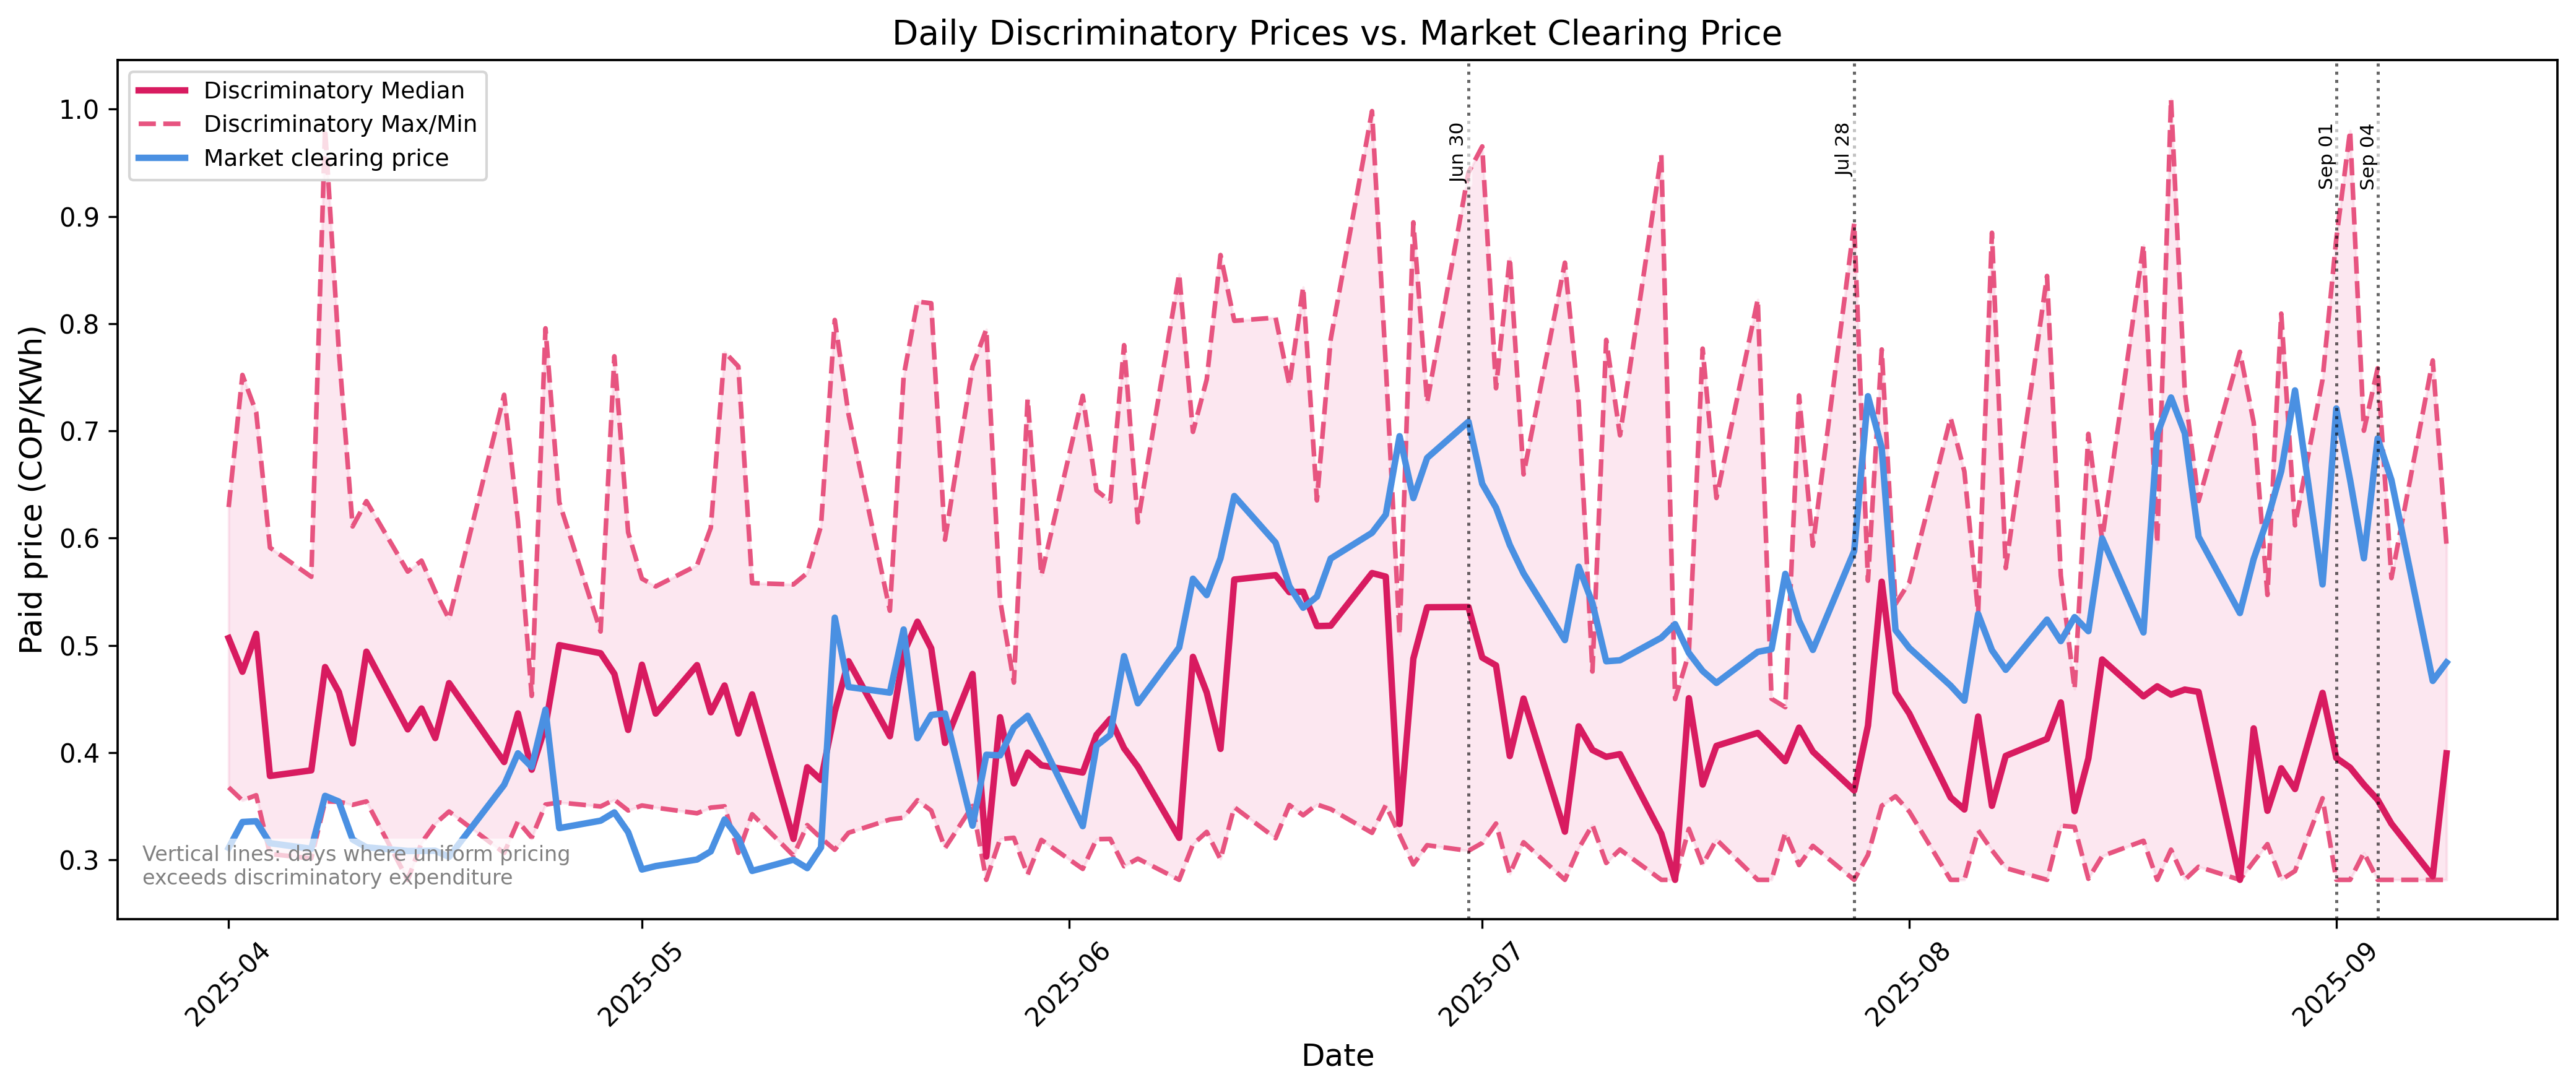

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

df_uni_hourlyReal["Fecha"] = pd.to_datetime(df_uni_hourlyReal["Fecha"])
df_dis_hourly["Fecha"] = pd.to_datetime(df_dis_hourly["Fecha"])

df_uni_no0 = df_uni_hourlyReal[df_uni_hourlyReal["precio_pagado"] != 0].copy()
df_dis_no0 = df_dis_hourly[df_dis_hourly["precio_pagado"] != 0].copy()

df_uni_no0["dia"] = df_uni_no0["Fecha"].dt.date
df_dis_no0["dia"] = df_dis_no0["Fecha"].dt.date

res_dis_dia = (
    df_dis_no0
    .groupby("dia")["precio_pagado"]
    .agg(minimo="min", mediana="median", maximo="max")
    .reset_index()
)
res_uni_dia = (
    df_uni_no0
    .groupby("dia")["precio_pagado"]
    .mean()
    .reset_index(name="media_uniforme")
)

comp_dia = res_dis_dia.merge(res_uni_dia, on="dia", how="inner")
comp_dia["dia"] = pd.to_datetime(comp_dia["dia"])

# ── Días clave: donde uniform pierde ──────────────────────────────────────
mask = (
    ingreso_por_dia_uniforme["ingreso_total_dia"].values
    > ingreso_por_dia_discriminatorio["ingreso_total_dia"].values
)
dias_clave = pd.to_datetime(ingreso_por_dia_uniformeReal.loc[mask, "Fecha"])

print(f"Días donde uniform pierde: {len(dias_clave)}")
print(dias_clave.dt.strftime("%Y-%m-%d").tolist())

# ── Figura ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Sombra rango discriminatorio
ax.fill_between(
    comp_dia["dia"],
    comp_dia["minimo"],
    comp_dia["maximo"],
    color="#f4a3c4", alpha=0.25,
)

# Líneas discriminatorio
ax.plot(comp_dia["dia"], comp_dia["minimo"],
        linestyle="--", linewidth=1.8, color="#e75480")
ax.plot(comp_dia["dia"], comp_dia["mediana"],
        linewidth=2.5, color="#d81b60", label="Discriminatory Median")
ax.plot(comp_dia["dia"], comp_dia["maximo"],
        linestyle="--", linewidth=1.8, color="#e75480",
        label="Discriminatory Max/Min")

# Market clearing price
ax.plot(comp_dia["dia"], comp_dia["media_uniforme"],
        linewidth=2.5, color="#4a90e2", label="Market clearing price")

# ── Líneas verticales: días donde uniform pierde ──────────────────────────
ymin, ymax = comp_dia["minimo"].min(), comp_dia["maximo"].max()
y_text = ymax - (ymax - ymin) * 0.03

for fecha in dias_clave:
    ax.axvline(x=fecha, color="black", linestyle=":", linewidth=1.2, alpha=0.6)
    ax.text(
        fecha, y_text,
        fecha.strftime("%b %d"),
        rotation=90, fontsize=7.5,
        color="black", ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
    )

# Nota en la figura
ax.annotate(
    "Vertical lines: days where uniform pricing\nexceeds discriminatory expenditure",
    xy=(0.01, 0.04), xycoords="axes fraction",
    fontsize=8, color="gray",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none")
)

# ── Formato ────────────────────────────────────────────────────────────────
ax.set_xlabel("Date")
ax.set_ylabel("Paid price (COP/KWh)")
ax.set_title("Daily Discriminatory Prices vs. Market Clearing Price")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(f'symmetric/{G}redes{estadistica}/PABClearing_{T}.png', dpi=300, bbox_inches='tight')
plt.show()

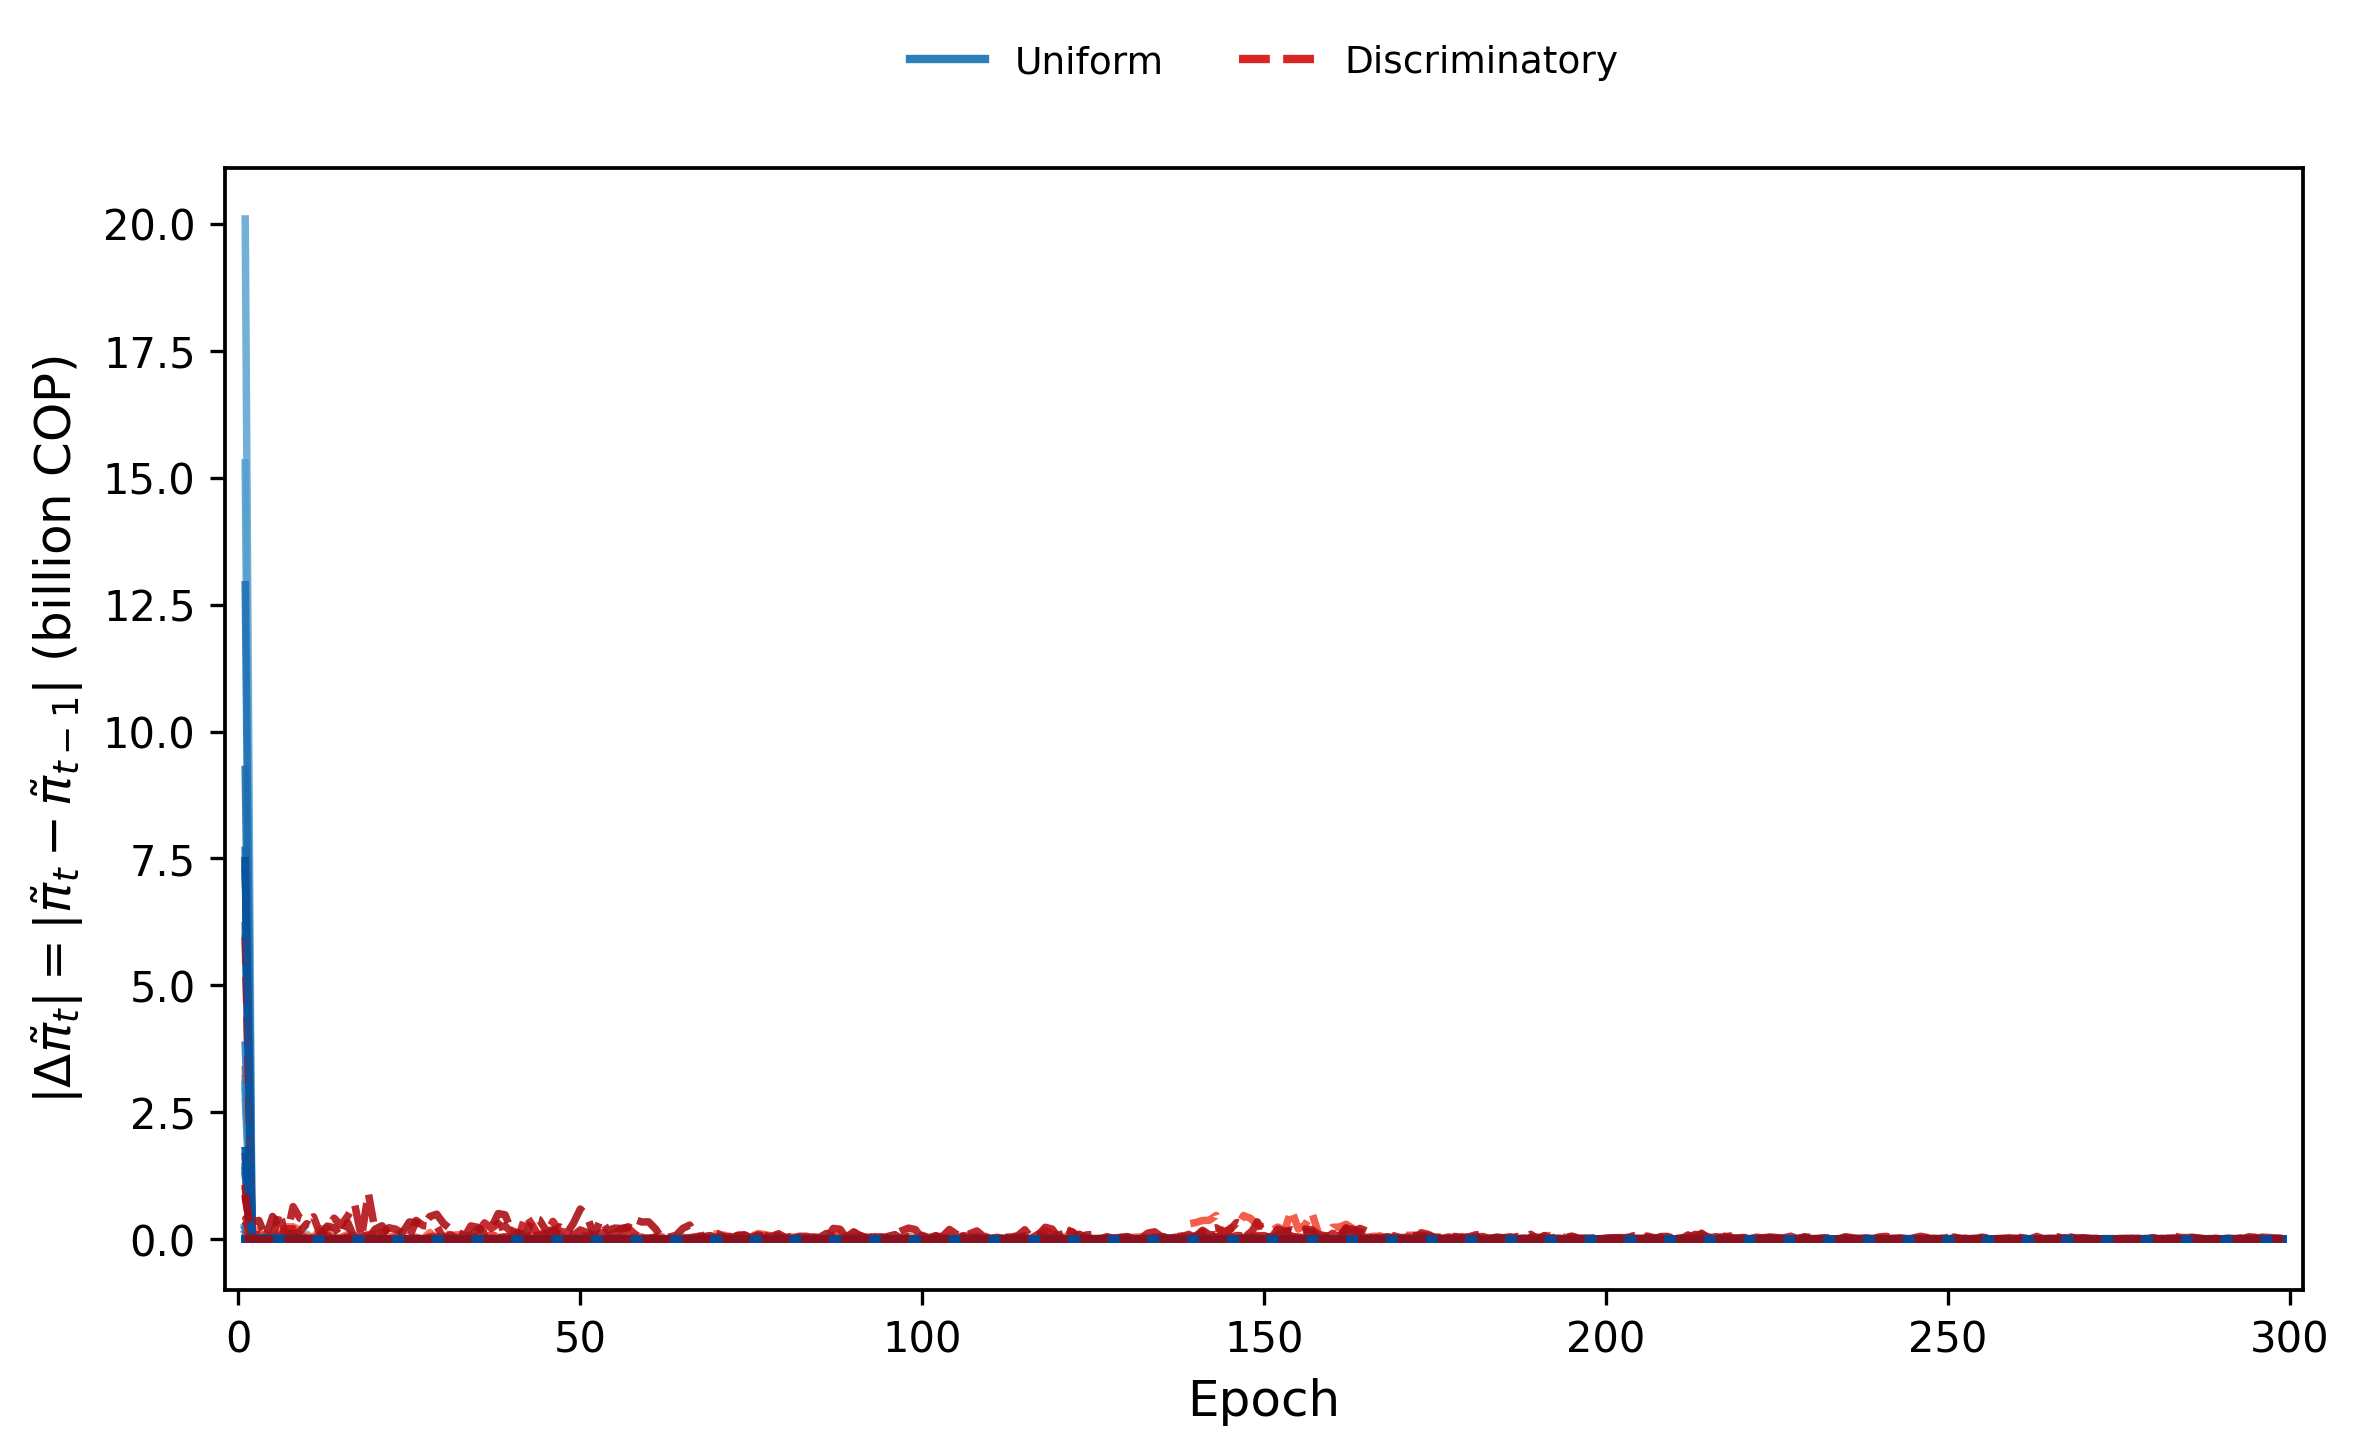

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.lines import Line2D
import numpy as np

# -----------------------------
# Cargar datos
# -----------------------------
u_uniform = pd.read_csv(f'symmetric/{G}redes{estadistica}/u_group_by_t_uniform_{T}.csv')
u_pab     = pd.read_csv(f'symmetric/{G}redes{estadistica}/u_group_by_t_pay_as_bid_{T}.csv')

# -----------------------------
# Calcular diferencias absolutas: |u_t - u_{t-1}|
# -----------------------------
du_uniform = u_uniform.copy()
du_pab = u_pab.copy()

group_cols = [f"grupo{g}" for g in range(1, G + 1)]

du_uniform[group_cols] = u_uniform[group_cols].diff().abs()
du_pab[group_cols] = u_pab[group_cols].diff().abs()

# quitar primera fila porque diff da NaN
du_uniform = du_uniform.iloc[1:].copy()
du_pab = du_pab.iloc[1:].copy()

# -----------------------------
# Estilo
# -----------------------------
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.8,
})

fig, ax = plt.subplots(figsize=(8, 5))

blue_shades = plt.cm.Blues(np.linspace(0.45, 0.9, G))
red_shades  = plt.cm.Reds(np.linspace(0.45, 0.9, G))

# -----------------------------
# Graficar |delta u|
# -----------------------------
for g in range(1, G + 1):
    ax.plot(
        du_uniform["t"],
        du_uniform[f"grupo{g}"],
        color=blue_shades[g - 1],
        linestyle="-",
        alpha=0.9
    )
    ax.plot(
        du_pab["t"],
        du_pab[f"grupo{g}"],
        color=red_shades[g - 1],
        linestyle="--",
        alpha=0.9
    )

ax.set_xlabel("Epoch")
from matplotlib.ticker import FuncFormatter

if G == 5:  # miles de millones
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e3:,.04f}"))
    ax.set_ylabel(r"$|\Delta \tilde{\pi}_t| = |\tilde{\pi}_t - \tilde{\pi}_{t-1}|$ (billion COP)")
    

elif G == 1:  # millones
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.4f}"))
    ax.set_ylabel(r"$|\Delta \tilde{\pi}_t| = |\tilde{\pi}_t - \tilde{\pi}_{t-1}|$ (millions COP)")

elif G == 36:  # billion
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e3:,.1f}"))
    ax.set_ylabel(r"$|\Delta \tilde{\pi}_t| = |\tilde{\pi}_t - \tilde{\pi}_{t-1}|$ (billion COP)")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)

ax.tick_params(axis='both', which='both', direction='out', top=False, right=False)
ax.margins(x=0.01, y=0.05)

legend_elements = [
    Line2D([0], [0], color=plt.cm.Blues(0.7), lw=2, linestyle='-',  label='Uniform'),
    Line2D([0], [0], color=plt.cm.Reds(0.7),  lw=2, linestyle='--', label='Discriminatory'),
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14),
    ncol=2,
    frameon=False
)

fig.tight_layout()
plt.savefig(f'symmetric/{G}redes{estadistica}/convergence_{T}.png', dpi=300, bbox_inches='tight')
plt.show()